# Vintage Resale Business - Data Analysis (2021-2025)

**Author:** Richard Rowe
**Skills:** Python · pandas · matplotlib · seaborn · pdfplumber · data cleaning
**GitHub:** [rrowe99](https://github.com/rrowe99)

---

I've been buying and reselling products online since 2021. What started with sneakers, Pokémon cards, and even crypto mining equipment gradually evolved into a vintage clothing and workwear business sold through eBay, Depop, Grailed, Instagram, and in person flea markets throughout New England.

This notebook turns five years of messy raw data (1099-K tax forms, marketplace CSV exports, handwritten market notes, and expense records) into a clean, visual business analysis.

**Questions this notebook answers:**
1. How did the business grow, and where did the money come from?
2. When do sales  happen? (online seasonality vs. market season)
3. Which sales channel is worth it? (price, fees, and take home by platform)
4. What actually makes money? (top items and 2022 item level ROI)
5. Is the business profitable? (revenue vs. expenses, 2024-2025)
6. Data limitations
7. Key takeaways & business implications

## Setup

In [39]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Data parsers (from src/parse_data.py)
from parse_data import (
    parse_item_csvs, parse_1099s, 
    build_annual_summary, build_expenses, build_market_events,
    parse_ebay_transactions, parse_depop_sales, build_notable_items,
    parse_market_notes,
)

# Styling
PALETTE = {
    "ebay":     "#E53238",
    "grailed":   "#1B1B1B",
    "depop":     "#FF2300",
    "market":    "#4A90D9",
    "instagram": "#C13584",
}
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "font.size": 11})
print("✅ Imports ready")

✅ Imports ready


## Data Sources

The raw data comes from four different source types:
- **CSV exports**: Flyp inventory tracker (2022), eBay Seller Hub, and Depop seller dashboard
- **1099-K PDFS**: IRS tax forms; monthly revenue is extracted with `pdfplumber` and regular expressions
- **Handwritten market notes**: ~900 individual market sales parsed from free form notes (two price formats, seller sections, expense lines) into item level data
- **Expense summaries**: annual expense breakdowns

A large part of this project was cleaning and standardizing these sources before any analysis could be done. All extraction logic lives in `src/parse_data.py`

In [40]:
# Load all datasets
items   = parse_item_csvs()            # 2022 item level sales (Flyp)
ebay_tx = parse_ebay_transactions()     # eBay orders 2024-2025
depop_tx = parse_depop_sales()          # Depop sales 2023-2025
monthly = parse_1099s()                 # monthly 1099-K revenue by platform
annual = build_annual_summary()         # annual totals by platform
expenses = build_expenses()             # expense categories by year
markets = build_market_events()         # in person market events
market_items = parse_market_notes()    # item-level in-person sales

print(f"\nItems (2022):     {len(items)} sold items")
print(f"eBay transactions:  {len(ebay_tx)} orders | avg ${ebay_tx['revenue'].mean():.2f}")
print(f"Depop transactions: {len(depop_tx)} sales | avg ${depop_tx['revenue'].mean():.2f}")
print(f"Monthly revenue:    {len(monthly)} platform-months")
print(f"Annual summary:     {annual['year'].nunique()} years, {annual['platform'].nunique()} platforms")
print(f"Market events:      {len(markets)} events")
print(f"Market items:       {len(market_items)} itemized sales")

  ✓ Flyp CSVs: 59 sold items
  ✓ Transaction_report_20240101_20240331.csv: 11 orders
  ✓ Transaction_report_20240401_20240630.csv: 33 orders
  ✓ Transaction_report_20240701_20240930.csv: 27 orders
  ✓ Transaction_report_20241001_20241231.csv: 20 orders
  ✓ Transaction_report_20250101_20250331.csv: 36 orders
  ✓ Transaction_report_20250401_20250630.csv: 25 orders
  ✓ Transaction_report_20250701_20250930.csv: 38 orders
  → eBay total: 190 orders
  ✓ Depop Sales 02_01_2023 - 04_01_2023.csv: 13 sales
  ✓ Depop Sales 03_01_2024 - 05_29_2024.csv: 94 sales
  ✓ Depop Sales 04_01_2023 - 06_30_2023.csv: 23 sales
  ✓ Depop Sales 06_01_2024 - 08_31_2024.csv: 53 sales
  ✓ Depop Sales 07_01_2023 - 09_30_2023.csv: 20 sales
  ✓ Depop Sales 09_01_2024 - 11_30_2024.csv: 11 sales
  ✓ Depop Sales 10_01_2023 - 12_30_2023.csv: 77 sales
  ✓ Depop Sales 12_01_2023 - 02_29_2024.csv: 73 sales
  ✓ Depop Sales 12_01_2024 - 02_28_2025.csv: 14 sales
  → Depop total: 378 sales
 ✓ Paypal_1099K_2022.pdf: 11 months
 ✓ 

## 1. How did the business grow, and where did the money come from?

The business changed a lot over five years:
- **2021:** Sneakers and collectibles on eBay, before the vintage focus
- **2022:** Grailed (via Paypal) as the main channel; started new eBay in October
- **2023:** eBay became the main online channel; added Depop
- **2024:** First full season of in person flea markets
- **2025:** eBay grew; Depop wound down; the best single market day (Brimfield, May)

In [41]:
# Annual totals at a glance
summary = annual.groupby("year")["gross_revenue"].sum().reset_index()
summary.columns = ["Year", "Gross Revenue"]
summary["YoY Growth"] = summary["Gross Revenue"].pct_change().mul(100).round(1).astype(str) + "%"
summary["Gross Revenue"] = summary["Gross Revenue"].map("${:,.2f}".format)
print("=== Annual Revenue Summary ===")
display(summary)

=== Annual Revenue Summary ===


,Year,Gross Revenue,YoY Growth
0,2021,"$9,149.72",NaN
1,2022,"$8,265.94",-9.7%
2,2023,"$19,963.31",141.5%
3,2024,"$41,335.12",107.1%
4,2025,"$31,291.61",-24.3%


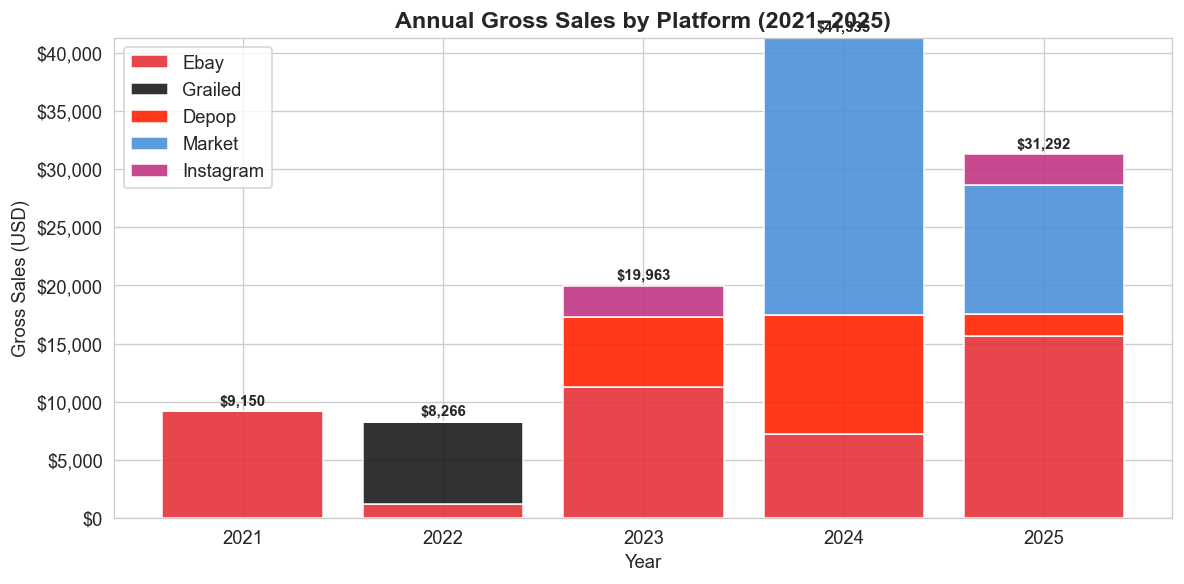

In [42]:
pivot = annual.pivot_table(
    index="year", columns="platform", values="gross_revenue", aggfunc="sum"
).fillna(0)

fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(pivot))
for plat, color in PALETTE.items():
    if plat in pivot.columns:
        ax.bar(pivot.index.astype(str), pivot[plat], bottom=bottom,
               label=plat.title(), color=color, alpha=0.9, edgecolor="white")
        bottom += pivot[plat].values

for i, total in enumerate(bottom):
    ax.text(i, total + 300, f"${total:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Annual Gross Sales by Platform (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../images/01_annual_sales_by_platform.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
# Group platforms into two channels: online marketplaces vs. in person (markets + Instagram contacts)
annual["channel"] = np.where(annual["platform"].isin(["market", "instagram"]), "In-person", "Online")

channel = annual.pivot_table(
    index="year", columns="channel", values="gross_revenue", aggfunc="sum"
).fillna(0)
channel["In-person %"] = channel["In-person"] / (channel["In-person"] + channel["Online"]) * 100

formatted = channel.copy()
formatted["Online"]      = formatted["Online"].map("${:,.0f}".format)
formatted["In-person"]   = formatted["In-person"].map("${:,.0f}".format)
formatted["In-person %"] = formatted["In-person %"].map("{:.1f}%".format)
display(formatted)

channel,In-person,Online,In-person %
year,,,
2021,$0,"$9,150",0.0%
2022,$0,"$8,266",0.0%
2023,"$2,700","$17,263",13.5%
2024,"$23,861","$17,474",57.7%
2025,"$13,770","$17,522",44.0%


In [44]:
# Break online sales into volume x price
online = annual[annual["channel"] == "Online"].groupby("year").agg(
    sales=("gross_revenue", "sum"),
    transactions=("num_transactions", "sum"),
)
online["avg_per_sale"] = online["sales"] / online["transactions"]

formatted = online.copy()
formatted["sales"]        = formatted["sales"].map("${:,.0f}".format)
formatted["avg_per_sale"] = formatted["avg_per_sale"].map("${:,.0f}".format)
display(formatted)

,sales,transactions,avg_per_sale
year,,,
2021,"$9,150",33,$277
2022,"$8,266",59,$140
2023,"$17,263",178,$97
2024,"$17,474",303,$58
2025,"$17,522",185,$95


**Finding:**
- **Online sales were flat (~$17.5k/year, 2023–2025), but the online business model changed.** 2024 ran on volume (303 sales averaging $58, driven by Depop); 2025 brought in the same money from 118 fewer sales averaging $95 (driven by eBay). Fewer, higher value sales means less time spent listing, packing, and shipping for the same revenue.
- **Nearly all growth after 2023 came from in-person selling**, rising from $2.7k in 2023 to $23.9k in 2024, almost 58% of that year's sales.
- **Average sale price tells the story of the pivot**: $277 in 2021 (sneakers) down to $58–$97 as the business shifted to vintage clothing.

*Note: 2021 reflects a different product mix (sneakers/collectibles), and 2022 eBay covers only Oct–Dec, so growth from 2021–2022 isn't a like-for-like comparison.*

## 2. When do sales happen?

Two different calendars drive this business: online sales can happen any month, while in person markets are seasonal (mostly June-November in New England). This section looks at online seasonality first, then at how the market season fits around it.

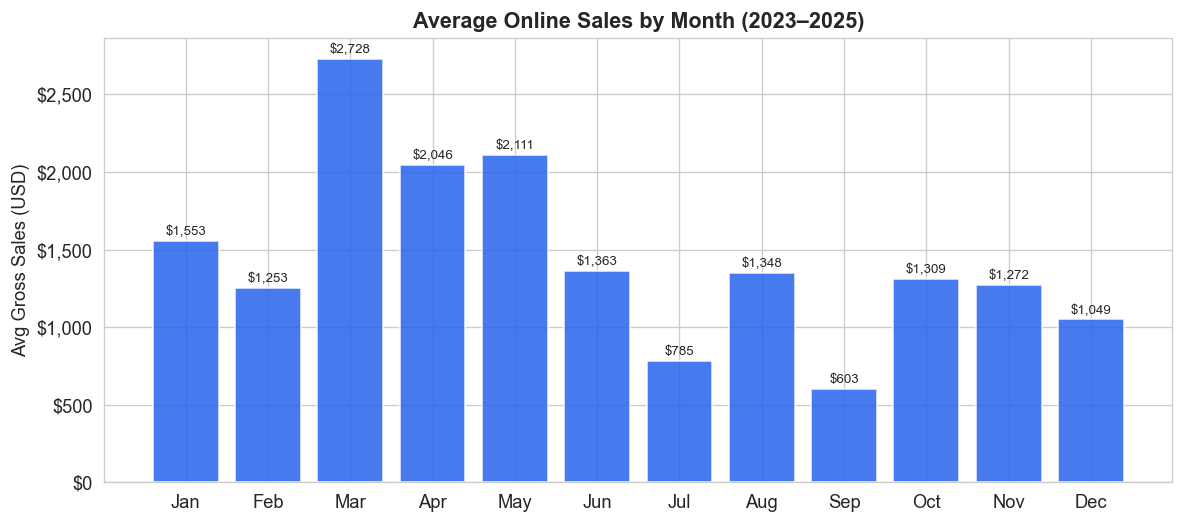

Strongest month: March ($2,728 avg)
Weakest month:   September ($603 avg)


In [45]:
import calendar

# Online sales by calendar month, averaged over the three full years (2023-2025)
online_months = monthly[monthly["year"].between(2023, 2025)].pivot_table(
    index="year", columns="month", values="gross_revenue", aggfunc="sum"
).reindex(columns=range(1, 13)).fillna(0)

seasonal = online_months.mean()
month_names = [calendar.month_abbr[m] for m in seasonal.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(month_names, seasonal.values, color="#2563EB", alpha=0.85, edgecolor="white")
for bar, val in zip(bars, seasonal.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 40, f"${val:,.0f}", ha="center", fontsize=8)

ax.set_title("Average Online Sales by Month (2023–2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../images/02_online_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Strongest month: {calendar.month_name[seasonal.idxmax()]} (${seasonal.max():,.0f} avg)")
print(f"Weakest month:   {calendar.month_name[seasonal.idxmin()]} (${seasonal.min():,.0f} avg)")

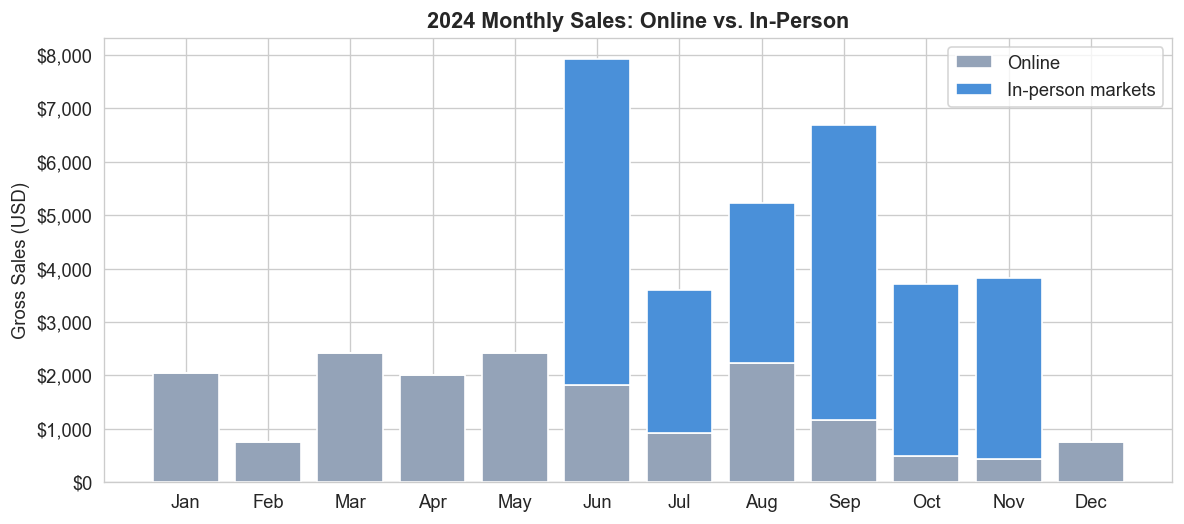

Online sales Jan-May (5 months, before markets): $9,638
Online sales Jun-Nov (6 months, market season):  $7,074
In-person sales Jun-Nov:                         $23,861


In [46]:
y = 2024
online_by_month   = monthly[monthly["year"] == y].groupby("month")["gross_revenue"].sum().reindex(range(1, 13), fill_value=0)
inperson_by_month = markets[markets["year"] == y].groupby("month")["richie_revenue"].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [calendar.month_abbr[m] for m in range(1, 13)]
ax.bar(labels, online_by_month.values, label="Online", color="#94A3B8", edgecolor="white")
ax.bar(labels, inperson_by_month.values, bottom=online_by_month.values,
       label="In-person markets", color=PALETTE["market"], edgecolor="white")

ax.set_title(f"{y} Monthly Sales: Online vs. In-Person", fontsize=13, fontweight="bold")
ax.set_ylabel("Gross Sales (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../images/03_2024_online_vs_inperson_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

pre_season = online_by_month.loc[1:5].sum()
in_season  = online_by_month.loc[6:11].sum()
print(f"Online sales Jan-May (5 months, before markets): ${pre_season:,.0f}")
print(f"Online sales Jun-Nov (6 months, market season):  ${in_season:,.0f}")
print(f"In-person sales Jun-Nov:                         ${inperson_by_month.sum():,.0f}")

**Finding:**
- **Spring is the strongest online season, not the holidays.** March averages ~$2,700 in online sales, and March–May are consistently the best stretch. November–December average only ~$1,000–1,300.
- **Fall is the online low point**: September is the weakest month on average (~$600), and October–December stay below spring levels.
- **Markets fill part of the gap.** The 2024 market season (June–November) brought in $23,900, peaking in June (~$6.1k) and September (~$5.5k).
- **Online sales dropped during market season.** In 2024, online sales over six market months ($7.1k) were lower than in the five months before markets started ($9.6k), with October–November falling below $500 each.

*Owner context: the fall slowdown lines up with the school calendar. From September onward I was back in school and spending less time listing and shipping, while weekend markets competed for the time I did have. This seasonality reflects my available time as much as buyer demand, so the holiday dip shouldn't be read as low demand for vintage clothing in Q4.*

## 3. Which sales channel is worth it?

Comparing channels faily takes care. eBay's reported "revenue" includes the shipping the buyer paid, while Depop's export lists item price and buyer shipping separately. To compare them on equal terms, this section measures both platforms the same way:
-**Gross** = item price + buyer-paid shipping
- **Fee %** = total platform fees + total gross (weighted by dollars, not averaged per sale)
- **Take-home** = gross - platform fees (before shipping labels and cost of goods, which aren't tracked per sale)

In [47]:
# Put both platforms on the same basis: gross = item price + buyer-paid shipping
ebay  = ebay_tx.assign(item_price=ebay_tx["item_subtotal"], gross=ebay_tx["revenue"])
depop = depop_tx.assign(item_price=depop_tx["revenue"], gross=depop_tx["revenue"] + depop_tx["shipping_rev"])

online_tx = pd.concat([ebay, depop], ignore_index=True)[
    ["platform", "sold_date", "item_price", "gross", "platform_fee"]
]
online_tx["take_home"] = online_tx["gross"] - online_tx["platform_fee"]

compare = online_tx.groupby("platform").agg(
    sales=("gross", "count"),
    avg_item_price=("item_price", "mean"),
    median_item_price=("item_price", "median"),
    gross=("gross", "sum"),
    fees=("platform_fee", "sum"),
    take_home=("take_home", "sum"),
)
compare["fee_pct"] = compare["fees"] / compare["gross"] * 100
compare["take_home_per_sale"] = compare["take_home"] / compare["sales"]

display(compare.round(2))

,sales,avg_item_price,median_item_price,gross,fees,take_home,fee_pct,take_home_per_sale
platform,,,,,,,,
depop,378,35.68,30.0,16591.06,2114.7,14476.36,12.75,38.30
ebay,190,86.29,50.0,18182.15,2515.0,15667.15,13.83,82.46


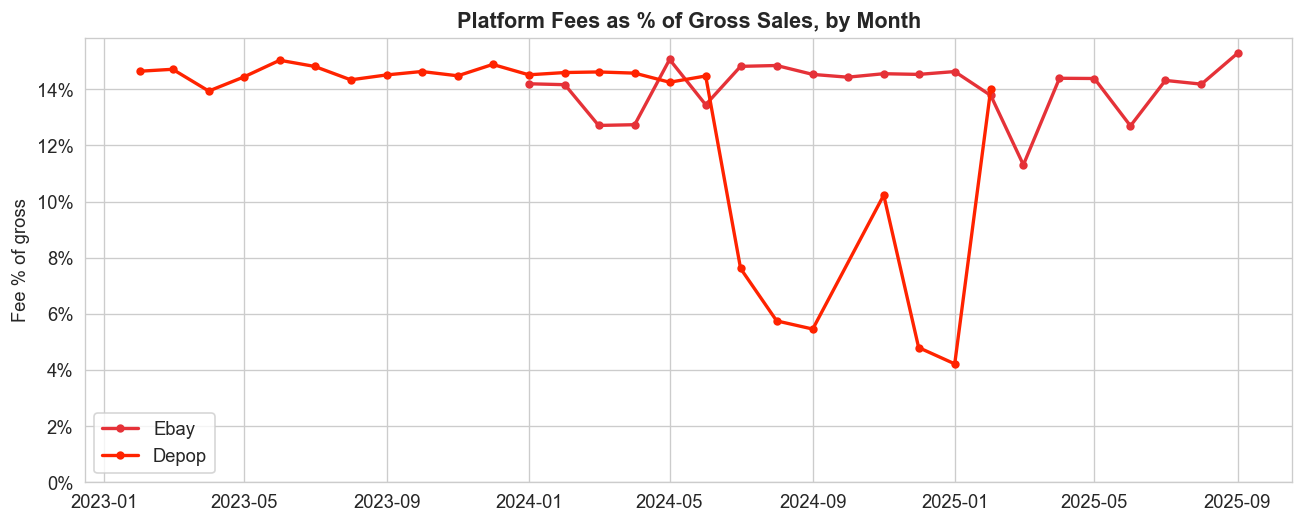

In [48]:
online_tx["month"] = online_tx["sold_date"].dt.to_period("M").dt.to_timestamp()

fee_trend = online_tx.groupby(["month", "platform"]).agg(
    gross=("gross", "sum"), fees=("platform_fee", "sum")
).reset_index()
fee_trend["fee_pct"] = fee_trend["fees"] / fee_trend["gross"] * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
for plat in ["ebay", "depop"]:
    d = fee_trend[fee_trend["platform"] == plat]
    ax.plot(d["month"], d["fee_pct"], marker="o", markersize=4, linewidth=2,
            color=PALETTE[plat], label=plat.title())

ax.set_title("Platform Fees as % of Gross Sales, by Month", fontsize=13, fontweight="bold")
ax.set_ylabel("Fee % of gross")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.savefig("../images/04_platform_fee_rate_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:**
- **On fees alone, Depop was the cheaper platform.** Measured on the same basis (fees ÷ item price + buyer shipping), Depop took 12.6% vs. eBay's 13.8%. Depop's fee rate also fell from ~14.5% to ~5–6% starting in July 2024, which matches Depop removing its 10% selling fee for US sellers in mid-2024. eBay's stayed flat at ~14%.
- **But eBay paid more than twice as much per sale.** eBay's typical item sold for more (median $50 vs. $30), so each eBay sale brought in **$83 in take-home vs. $39 on Depop**. Every sale takes roughly the same work to photograph, list, pack, and ship, so take home per sale matters more than fee percentage.
- **This explains the shift from Depop to eBay in 2025**: Depop sold more items, but eBay paid much better for the same effort. It's also the reason 2025 matched 2024's online sales with 118 fewer orders (Question 1). Notably, this shift happened *after* Depop cut its fees, so lower fees alone weren't enough to keep lower priced items online.

*Owner context: the shift was deliberate. Lower priced items (the typical ~$30 Depop sale) weren't worth the time to photograph, list, and ship when they sold quickly at in person markets with none of that work. I moved those items to markets and kept online listings, mainly eBay, for higher value pieces where the take home justified the effort.*

*Methodology note: an earlier version of this analysis reported Depop fees as higher (17.4% vs 14.6%). That comparison divided Depop fees by item price only while eBay's figure included shipping, and it averaged per-sale percentages instead of weighting by dollars. Both issues are corrected here.*

### In-person markets

Markets work differently from online platforms: there are no per-sale fees, but each market day has an upfront vendor fee and takes a full day. Market sales were logged by hand (~875 itemized sales from 2024–2025), so this section can look at both individual sales and full market days.

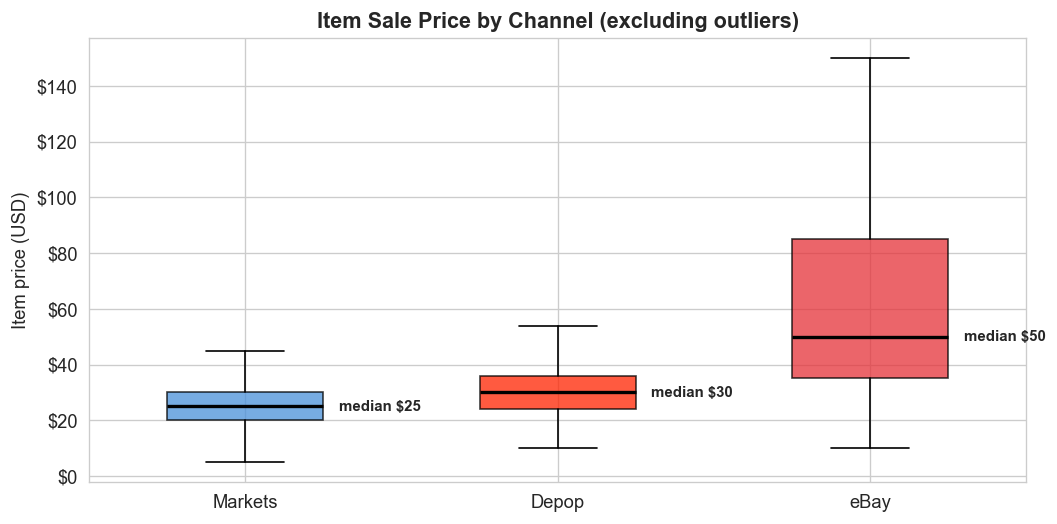

Market sales logged:       875
Median market sale:        $25
Sales at $30 or less:      77%
Sales at $100 or more:     2.3%


In [49]:
market_sales = market_items[
    (market_items["date"].dt.year <= 2025)
    & (market_items["venue"] != "Instagram")
    & (~market_items["item"].fillna("").str.startswith("Unrecorded"))
]

prices = [market_sales["price"], depop_tx["revenue"], ebay_tx["item_subtotal"]]
labels = ["Markets", "Depop", "eBay"]
colors = [PALETTE["market"], PALETTE["depop"], PALETTE["ebay"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot(prices, tick_labels=labels, showfliers=False, patch_artist=True,
                widths=0.5, medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for i, p in enumerate(prices, start=1):
    ax.text(i + 0.3, p.median(), f"median ${p.median():.0f}", va="center", fontsize=9, fontweight="bold")

ax.set_title("Item Sale Price by Channel (excluding outliers)", fontsize=13, fontweight="bold")
ax.set_ylabel("Item price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../images/05_item_price_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Market sales logged:       {len(market_sales)}")
print(f"Median market sale:        ${market_sales['price'].median():.0f}")
print(f"Sales at $30 or less:      {(market_sales['price'] <= 30).mean():.0%}")
print(f"Sales at $100 or more:     {(market_sales['price'] >= 100).mean():.1%}")

In [50]:
days = markets[(markets["year"] <= 2025) & (markets["event"] != "Instagram")]

yearly = days.groupby("year").agg(
    market_days=("days", "sum"),
    sales=("richie_revenue", "sum"),
    best_day=("richie_revenue", "max"),
)
yearly["vendor_fees"]         = expenses[expenses["category"] == "Market Vendor Fees"].set_index("year")["amount"]
yearly["fees_pct_of_sales"]   = yearly["vendor_fees"] / yearly["sales"] * 100
yearly["sales_per_day"]       = yearly["sales"] / yearly["market_days"]
yearly["sales_excl_best_day"] = yearly["sales"] - yearly["best_day"]
display(yearly.round(1))

,market_days,sales,best_day,vendor_fees,fees_pct_of_sales,sales_per_day,sales_excl_best_day
year,,,,,,,
2024,31,23861.0,2176.5,1898.0,8.0,769.7,21684.5
2025,7,11135.0,8500.0,2345.0,21.1,1590.7,2635.0


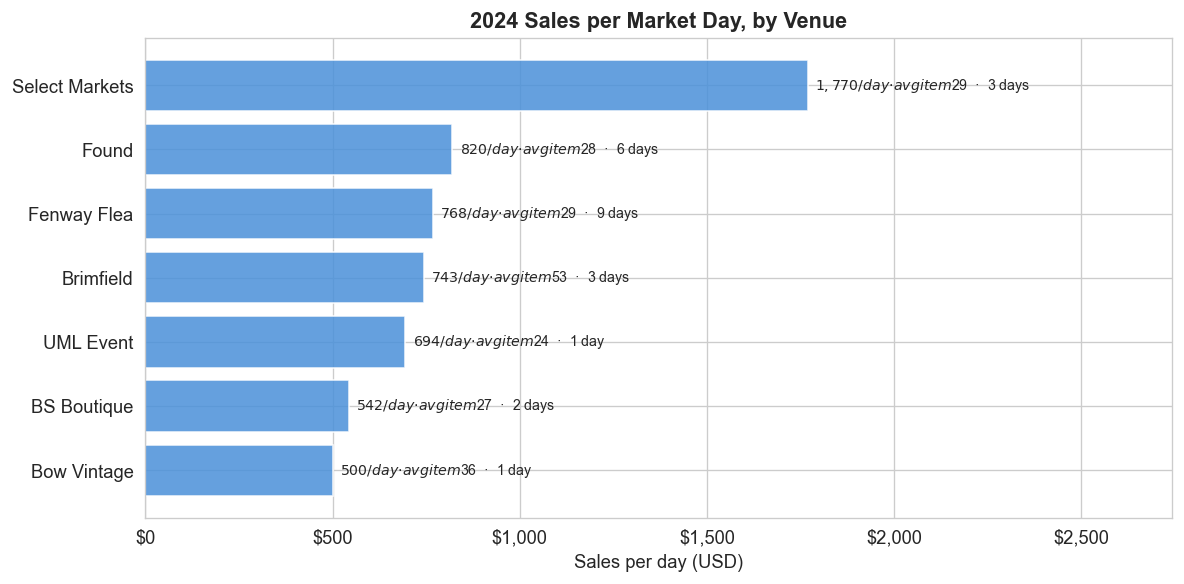

In [51]:
v24 = markets[(markets["year"] == 2024) & (~markets["event"].str.contains("weekend"))]

venues = v24.groupby("event").agg(
    days=("days", "sum"),
    sales=("richie_revenue", "sum"),
    items=("items", "sum"),
)
venues["per_day"]  = venues["sales"] / venues["days"]
venues["avg_item"] = venues["sales"] / venues["items"]
venues = venues.sort_values("per_day")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(venues.index, venues["per_day"], color=PALETTE["market"], alpha=0.85, edgecolor="white")
for bar, (_, row) in zip(bars, venues.iterrows()):
    label = f"${row['per_day']:,.0f}/day  ·  avg item ${row['avg_item']:.0f}  ·  {int(row['days'])} day{'s' if row['days'] > 1 else ''}"
    ax.text(row["per_day"] + 20, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=8.5)

ax.set_title("2024 Sales per Market Day, by Venue", fontsize=13, fontweight="bold")
ax.set_xlabel("Sales per day (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlim(0, venues["per_day"].max() * 1.55)
plt.tight_layout()
plt.savefig("../images/06_2024_sales_per_market_day_by_venue.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:**
- **Markets are where low-priced inventory sells.** The median market sale was $25, vs. $30 on Depop and $50 on eBay; 77% of market sales were $30 or less, and only 2% were $100+. This matches the deliberate strategy of moving lower-priced items to markets instead of listing them online.
- **2024 markets were a strong, high-volume channel.** 31 market days brought in $23,861 (~$770/day, ~26 items/day). Vendor fees were only 8% of market sales, leaving about $710 per day, roughly the take-home of **8–9 eBay sales**, with no photos, listings, or shipping.
- **Venue choice mattered a lot.** Select Markets averaged ~$1,770/day (about 60 items/day), more than double any other venue. Fenway Flea, the most frequent market, averaged ~$770/day as a reliable baseline. Brimfield had the highest average item price (~$53), the venue where higher-value pieces sell. (Several venues have only 1–3 days of data.)
- **2025 depended on one day.** Brimfield in May ($8,500) was 76% of 2025 market sales. The other six market days brought in $2,635 combined, close to the $2,345 paid in vendor fees that year, so outside of Brimfield, 2025 markets roughly broke even before cost of goods.

## 4. What actually makes money?

This section combines every individually recorded sale into one table: eBay and Depop orders, 2022 Flyp items, and itemized market and Instagram sales. That makes it possible to compare sales by size across all channels.

In [52]:
ebay_items = pd.DataFrame({"channel": "eBay",  "date": ebay_tx["sold_date"],
                           "item": ebay_tx["name"],  "price": ebay_tx["item_subtotal"]})
depop_items = pd.DataFrame({"channel": "Depop", "date": depop_tx["sold_date"],
                            "item": depop_tx["name"], "price": depop_tx["revenue"]})
flyp_items = pd.DataFrame({"channel": items["platform"].map({"ebay": "eBay", "grailed": "Grailed", "instagram": "Instagram"}),
                           "date": items["sold_date"].dt.tz_localize(None),
                           "item": items["name"], "price": items["revenue"]})
in_person_items = pd.DataFrame({"channel": np.where(market_items["venue"] == "Instagram", "Instagram", "Market"),
                                "date": market_items["date"], "item": market_items["item"], "price": market_items["price"]})

all_sales = pd.concat([ebay_items, depop_items, flyp_items, in_person_items], ignore_index=True)
all_sales = all_sales[(all_sales["date"].dt.year <= 2025)
                      & (~all_sales["item"].fillna("").str.startswith("Unrecorded"))]

total_gross = annual["gross_revenue"].sum()
print(f"Itemized sales: {len(all_sales):,} sales, ${all_sales['price'].sum():,.0f}")
print(f"Coverage: {all_sales['price'].sum() / total_gross:.0%} of all gross sales (2021–2025)")
print(all_sales["channel"].value_counts().to_string())

Itemized sales: 1,504 sales, $71,881
Coverage: 65% of all gross sales (2021–2025)
channel
Market       875
Depop        378
eBay         202
Grailed       46
Instagram      3


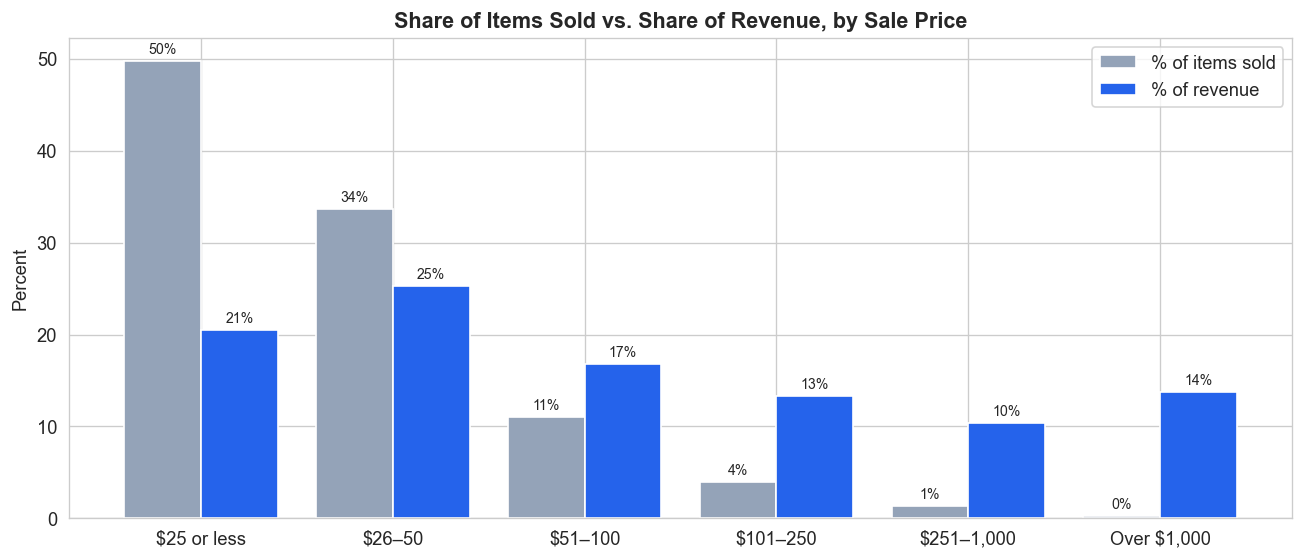

Top 1% of sales (15 items) = 21% of itemized revenue
Top 10% of sales (150 items) = 46% of itemized revenue


In [53]:
labels = ["$25 or less", "$26–50", "$51–100", "$101–250", "$251–1,000", "Over $1,000"]
all_sales["price_band"] = pd.cut(all_sales["price"], bins=[0, 25, 50, 100, 250, 1000, 10000], labels=labels)

bands = all_sales.groupby("price_band", observed=True)["price"].agg(sales="count", revenue="sum")
bands["pct_of_sales"]   = bands["sales"] / bands["sales"].sum() * 100
bands["pct_of_revenue"] = bands["revenue"] / bands["revenue"].sum() * 100

x = np.arange(len(bands))
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - 0.2, bands["pct_of_sales"],   width=0.4, label="% of items sold", color="#94A3B8")
ax.bar(x + 0.2, bands["pct_of_revenue"], width=0.4, label="% of revenue",    color="#2563EB")
for i, (s, r) in enumerate(zip(bands["pct_of_sales"], bands["pct_of_revenue"])):
    ax.text(i - 0.2, s + 0.8, f"{s:.0f}%", ha="center", fontsize=8.5)
    ax.text(i + 0.2, r + 0.8, f"{r:.0f}%", ha="center", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(bands.index)
ax.set_title("Share of Items Sold vs. Share of Revenue, by Sale Price", fontsize=13, fontweight="bold")
ax.set_ylabel("Percent")
ax.legend()
plt.tight_layout()
plt.savefig("../images/07_sales_vs_revenue_by_price_band.png", dpi=150, bbox_inches="tight")
plt.show()

ranked = all_sales["price"].sort_values(ascending=False)
for pct in [0.01, 0.10]:
    n = round(len(ranked) * pct)
    print(f"Top {pct:.0%} of sales ({n} items) = {ranked.head(n).sum() / ranked.sum():.0%} of itemized revenue")

In [54]:
top10 = all_sales.nlargest(10, "price")[["date", "channel", "item", "price"]].copy()
top10["date"]  = top10["date"].dt.strftime("%Y-%m-%d")
top10["item"]  = top10["item"].str[:60]
top10["price"] = top10["price"].map("${:,.0f}".format)
display(top10.reset_index(drop=True))

,date,channel,item,price
0,2025-05-13,Market,1940s Levi’s 506xx First Edition Type 1 Denim ...,"$5,000"
1,2025-09-16,Instagram,four 80s LL Bean Deluxe Boat and Tote Bags - x...,"$2,250"
2,2025-02-26,eBay,Vintage 60s Levis Type 2 II Denim Jacket Origi...,"$1,430"
3,2025-05-13,Market,80s LL Bean 2-Way Boat and Tote Backpack,"$1,200"
4,2025-03-22,eBay,NIKE SB DUNK HIGH USED SIZE 11 MF DOOM BLACK M...,$850
5,2025-08-23,eBay,Vintage 80s Polo Ralph Lauren Western Cowboy R...,$550
6,2025-09-04,Market,80s LL bean deluxe tote,$500
7,2022-11-30,eBay,Jordan 5 Retro OFF-WHITE Sail,$447
8,2022-08-09,Grailed,Birkenstock Boston Clog Stussy Dusty Pink (2021),$428
9,2025-12-13,Instagram,80s LL Bean Deluxe Boat and Tote Bag - tall,$385


**Finding:**
- **Most sales are small, but a few big sales bring in a large share of the money.** Half of all itemized sales were $25 or less, yet together they brought in only ~21% of revenue. The 4 sales over $1,000 (0.3% of items) brought in ~14%.
- **Revenue is concentrated at the top**: the top 1% of sales (15 items) made up ~21% of itemized revenue, and the top 10% made up ~46%.
- **The biggest wins come from two categories: vintage Levi's denim and 1980s L.L.Bean bags.** Between them they account for 6 of the top 10 sales, including the two largest Levi's jackets ($5,000 and $1,430) and four L.L.Bean bag sales ($2,250, $1,200, $500, $385).
- **Both halves of the business matter.** High-volume $25 sales keep markets running and cover costs; finding rare pieces drives the upside. The best year, 2025's Brimfield day, came from a single $5,000 jacket.

*Coverage: itemized sales account for ~$70k (64%) of ~$110k in total gross sales. 2021 and 2023 eBay sales exist only as totals.*

### Profit per item

Cost of goods (what I paid for each item) was only tracked item by item in 2022, through the Flyp inventory app, and for a curated list of notable sales. So per item profit can only be measured for those two groups. 2022 was mostly sneakers and streetwear sold on Grailed; the notable list spans 2021–2025, from sneakers to vintage.

In [55]:
cost_known = items[items["cog"] > 0].copy()

revenue = cost_known["revenue"].sum()
cost    = cost_known["cog"].sum()
profit  = cost_known["profit"].sum()
print(f"2022 items with known cost: {len(cost_known)}")
print(f"Payout (after platform fees): ${revenue:,.0f}")
print(f"Cost of goods:                ${cost:,.0f}")
print(f"Profit:                       ${profit:,.0f}  ({profit / revenue:.1%} margin)")
print(f"Median ROI per item:          {cost_known['roi_pct'].median():.0f}%")
print(f"Items sold at a loss:         {(cost_known['profit'] < 0).sum()} of {len(cost_known)}")

cost_known["cost_band"] = pd.cut(cost_known["cog"], bins=[0, 25, 100, 10000],
                                 labels=["Paid $25 or less", "Paid $26–100", "Paid over $100"])
by_cost = cost_known.groupby("cost_band", observed=True).agg(
    items=("cog", "count"),
    total_profit=("profit", "sum"),
    median_roi=("roi_pct", "median"),
)
display(by_cost.round(1))

2022 items with known cost: 53
Payout (after platform fees): $6,603
Cost of goods:                $5,512
Profit:                       $1,091  (16.5% margin)
Median ROI per item:          14%
Items sold at a loss:         14 of 53


,items,total_profit,median_roi
cost_band,,,
Paid $25 or less,12,102.1,126.2
Paid $26–100,20,287.2,7.1
Paid over $100,21,701.2,11.1


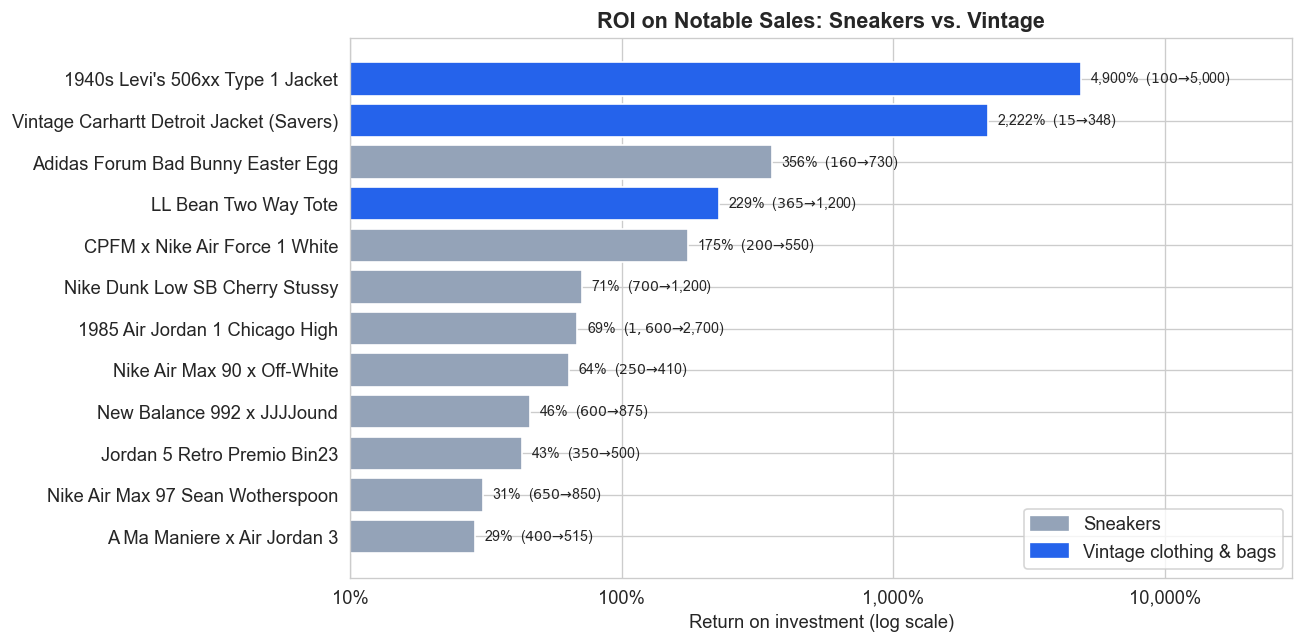

type
Sneakers                     64.0
Vintage clothing & bags    2222.0
Name: roi_pct, dtype: float64


In [56]:
notable = build_notable_items()
notable["type"] = np.where(notable["item"].str.contains("Levi|Carhartt|LL Bean", case=False),
                           "Vintage clothing & bags", "Sneakers")
notable = notable.sort_values("roi_pct")

type_colors = {"Sneakers": "#94A3B8", "Vintage clothing & bags": "#2563EB"}
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(notable["item"], notable["roi_pct"],
               color=[type_colors[t] for t in notable["type"]], edgecolor="white")
for bar, (_, row) in zip(bars, notable.iterrows()):
    ax.text(row["roi_pct"] * 1.08, bar.get_y() + bar.get_height() / 2,
            f"{row['roi_pct']:,.0f}%  (${row['cog']:,.0f} → ${row['revenue']:,.0f})", va="center", fontsize=8.5)

ax.set_xscale("log")
ax.set_xlim(10, notable["roi_pct"].max() * 6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}%"))
ax.set_title("ROI on Notable Sales: Sneakers vs. Vintage", fontsize=13, fontweight="bold")
ax.set_xlabel("Return on investment (log scale)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in type_colors.values()],
          labels=list(type_colors.keys()), loc="lower right")
plt.tight_layout()
plt.savefig("../images/08_notable_sales_roi.png", dpi=150, bbox_inches="tight")
plt.show()

print(notable.groupby("type")["roi_pct"].median().round(0))

**Finding:**
- **The 2022 sneaker/streetwear model had thin margins.** Across 53 items with known cost, I kept $1,091 profit on $6,603 in payouts, a 16.5% margin with a median ROI of 14%. More than 1 in 4 items (14 of 53) sold at a loss.
- **Cheap buys produced the best returns.** Items bought for $25 or less had a median ROI of 126%, versus 7–11% for items that cost more. Expensive inventory tied up the most money for the smallest percentage return.
- **Vintage finds beat sneakers by a wide margin.** Among notable sales, sneakers returned a median ~64%, while vintage pieces returned a median ~2,200%: a $15 Carhartt jacket sold for $348, and a $100 Levi's 506xx sold for $5,000. Sneakers need large upfront cost for modest returns; vintage is bought cheaply at thrift stores and flea markets, where knowing what to look for is the advantage.
- **This is the data behind the pivot from sneakers to vintage**, and it connects to Question 3: the business makes money from low-cost inventory, whether that means cheap pieces sold in volume at markets or rare finds with outsized returns.

*Note: the notable list is hand picked best sales, so it shows the upside, not typical results. 2022 is the only year with complete item-level cost data.*

## 5. Is the business profitable?

Expense records exist for 2024 and 2025: platform fees, shipping, market vendor fees, supplies, and cost of goods. One important gap: **recorded cost of goods only covers items sold online.** What I paid for items sold in person was never tracked as an expense.

To fill that gap without guessing a single number, in-person inventory cost is estimated as a **range**:
- Where I know the actual cost of a big sale (the Levi's 506xx, the L.L.Bean bags), the real cost is used.
- For everything else, cost is estimated at **20%, 35%, or 50%** of the sale price. This is based on my buying rule: I typically pay $2–10 for items that sell for $20–30, and I only buy items I expect to at least double my money on.

In [57]:
# Owner provided purchase costs for the largest in-person sales
KNOWN_COSTS = [
    ("2025-05-13", "506xx",          100),
    ("2025-05-13", "2-Way",          365),
    ("2025-09-16", "LL Bean",        1500),   # four totes sold together
    ("2025-12-13", "LL Bean",        340),
    ("2025-09-04", "deluxe tote",    350),
    ("2025-09-04", "beach backpack", 30),
    ("2025-09-04", "duffle",         20),
    ("2025-09-04", "harrington",     35),     # remembered as $30–40
]

ip = market_items[market_items["date"].dt.year.between(2024, 2025)].copy()
ip["known_cost"] = np.nan
for date, keyword, cost in KNOWN_COSTS:
    match = (ip["date"] == date) & ip["item"].str.contains(keyword, case=False, na=False)
    ip.loc[match, "known_cost"] = cost
print(f"Known costs matched: {ip['known_cost'].notna().sum()} of {len(KNOWN_COSTS)}")

scenarios = {"Low (20% of price)": 0.20, "Mid (35%)": 0.35, "High (50%)": 0.50}
rows = []
for year in [2024, 2025]:
    year_items = ip[ip["date"].dt.year == year]
    gross    = annual.loc[annual["year"] == year, "gross_revenue"].sum()
    recorded = expenses.loc[expenses["year"] == year, "amount"].sum()
    for name, ratio in scenarios.items():
        est_cost = year_items["known_cost"].fillna(year_items["price"] * ratio).sum()
        profit = gross - recorded - est_cost
        rows.append({"year": year, "scenario": name, "gross_sales": gross,
                     "recorded_expenses": recorded, "est_in_person_cog": est_cost,
                     "est_profit": profit, "margin_pct": profit / gross * 100})

profit_table = pd.DataFrame(rows)
display(profit_table.round(1))

Known costs matched: 8 of 8


,year,scenario,gross_sales,recorded_expenses,est_in_person_cog,est_profit,margin_pct
0,2024,Low (20% of price),41335.1,11760.1,4772.2,24802.8,60.0
1,2024,Mid (35%),41335.1,11760.1,8351.3,21223.7,51.3
2,2024,High (50%),41335.1,11760.1,11930.5,17644.5,42.7
3,2025,Low (20% of price),31291.6,13655.1,3525.0,14111.5,45.1
4,2025,Mid (35%),31291.6,13655.1,4113.8,13522.7,43.2
5,2025,High (50%),31291.6,13655.1,4702.5,12934.0,41.3


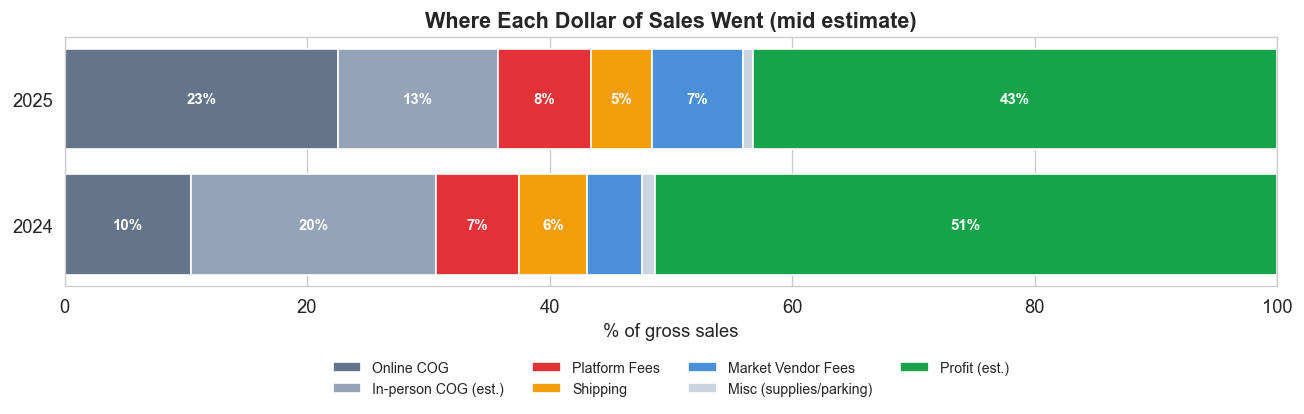

In [58]:
mid = profit_table[profit_table["scenario"].str.startswith("Mid")].set_index("year")

parts = expenses.pivot_table(index="year", columns="category", values="amount", aggfunc="sum")
parts["In-person COG (est.)"] = mid["est_in_person_cog"]
parts["Profit (est.)"]        = mid["est_profit"]
parts = parts.rename(columns={"Cost of Goods (COG)": "Online COG"})
order = ["Online COG", "In-person COG (est.)", "Platform Fees", "Shipping",
         "Market Vendor Fees", "Misc (supplies/parking)", "Profit (est.)"]
shares = parts[order].div(parts[order].sum(axis=1), axis=0) * 100

colors = ["#64748B", "#94A3B8", "#E53238", "#F59E0B", PALETTE["market"], "#CBD5E1", "#16A34A"]
fig, ax = plt.subplots(figsize=(11, 3.8))
left = np.zeros(len(shares))
for col, color in zip(order, colors):
    ax.barh(shares.index.astype(str), shares[col], left=left, color=color, edgecolor="white", label=col)
    for i, val in enumerate(shares[col]):
        if val >= 5:
            ax.text(left[i] + val / 2, i, f"{val:.0f}%", ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")
    left += shares[col].values

ax.set_title("Where Each Dollar of Sales Went (mid estimate)", fontsize=13, fontweight="bold")
ax.set_xlabel("% of gross sales")
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=8.5, frameon=False)
plt.tight_layout()
plt.savefig("../images/09_where_each_dollar_went.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:**
- **The business is solidly profitable.** Estimated profit was **$17.6k–$24.8k in 2024** (43–60% margin) and **$12.9k–$14.1k in 2025** (41–45%). The middle estimates are ~$21.2k and ~$13.5k.
- **The old 2025 profit figure ($1,111) was wrong by roughly $12,000.** It counted only eBay and Depop item sales ($14.8k) but subtracted every expense, including $2,345 in market vendor fees, while leaving out $13.8k in market and Instagram sales.
- **Inventory is the biggest cost**, about a third of sales in both years. Platform fees and shipping together take only ~12–13%.
- **2025 profit was lower than 2024 mainly because of inventory mix**: online cost of goods rose from ~10% to ~23% of sales as I bought more expensive pieces for eBay, and there were far fewer market days.

*Assumptions and limits: in-person inventory cost wasn't recorded, so it's estimated at 20–50% of sale price based on my buying rule, using actual costs for the six largest in-person sales. Profit is before income taxes and doesn't value my own time. 1099-K gross amounts may include sales tax collected by platforms, which would slightly overstate profit.*

## 6. Data Limitations

Every analysis here is shaped by what was and wasn't recorded. The main limits:

**Coverage**
- Itemized sales cover ~$72k (65%) of ~$110k in total gross sales. 2021 and 2023 eBay sales exist only as annual totals, and eBay transaction exports end in September 2025 (annual totals come from the full-year 1099-K).
- 2022 eBay data covers only October–December, and 2021 reflects a different product mix (sneakers and collectibles), so early year comparisons aren't like-for-like.

**Cost of goods**
- Per item cost exists only for 2022 (Flyp) and a hand picked list of notable sales.
- Recorded cost of goods for 2024–2025 covers online inventory only. In person inventory cost is **estimated** at 20–50% of sale price, using actual costs for the eight largest in person sales.
- Expenses are only available for 2024 and 2025, so profit can't be calculated for earlier years.

**Market notes**
- In-person sales come from handwritten notes parsed into ~875 itemized sales. Brimfield (May 2025) has only two itemized sales; the remaining $2,300 is recorded as one lump.
- One day's handwritten total differed from its itemized sum by $60; the itemized sum is used.
- Three market weekends were logged as one entry and can't be split by day.
- Sales by booth partners were excluded; only my own sales are counted.

**Definitions and samples**
- 1099-K "gross" includes buyer-paid shipping and may include sales tax collected by platforms. eBay and Depop report shipping differently, so they were normalized before comparing (Question 3).
- Several venue averages are based on 1–3 market days, and the notable sales list shows the best outcomes, not typical ones.
- Time spent (sourcing, listing, market days) was never tracked, so profit per hour can't be compared across channels.
- Some explanations, such as the school year slowdown and the pricing strategy, come from my own knowledge of the business and are labeled as owner context.

## 7. Key Takeaways & Business Implications

### What the data shows

| Question | Answer |
|---|---|
| **1. Growth** | ~$110k in gross sales (2021–2025). 2024 was the best year ($41.3k). Online sales held flat at ~$17.5k/year; **nearly all growth came from in-person selling**, which made up 58% of 2024 sales. |
| **2. Timing** | Spring is the strongest online season (March averages ~$2.7k), not the holidays. Fall is weakest, partly because school limited time for listing. Markets run June–November. |
| **3. Channels** | eBay paid **$82 per sale vs. $38 on Depop**, even though Depop's fees were lower. 2024 markets brought in ~$770/day with vendor fees of only 8% of sales; Select Markets led at ~$1,770/day. |
| **4. What makes money** | Half of all sales were $25 or less but brought in only ~21% of revenue; the top 10% of sales brought in ~46%. The biggest wins were vintage Levi's denim and 1980s L.L.Bean bags, and returns depended on how cheaply each item was sourced. |
| **5. Profit** | Estimated profit of ~$21k in 2024 and ~$13.5k in 2025 (mid estimates; 41–60% margins across scenarios). The previously recorded 2025 profit of $1,111 was understated by roughly $12,000. |

### Business implications

1. **Match each item to the channel that fits its price.** Items under ~$30 belong at markets, where they sell without photos, listings, or shipping. Items over ~$50 belong on eBay, where take-home per sale justifies the listing work. Depop falls in between and isn't worth the time.
2. **Choose markets by sales per day, not habit.** The best venues earned 2x the weakest. In 2025, markets other than Brimfield roughly broke even against vendor fees.
3. **List before spring.** With March as the online peak, the weeks before it are the best time to build up online inventory, especially before the fall semester slows things down.
4. **Profit is made when buying, not selling.** Items bought for $25 or less returned a median 126% in 2022, while famous-brand pieces bought near market value returned as little as 13%.
5. **Track what's missing.** Recording cost for every market item and hours per market day would turn the profit estimate into an exact number and make it possible to compare channels by profit per hour.

### Corrections made during this analysis

Rebuilding this project from raw sources caught several errors in earlier versions of the numbers:
- A hand typed estimate of **$8,000** in 2024 market sales was replaced by **$23,861** summed from ~800 itemized sales.
- A hand typed market log that didn't match the source notes (and was missing three market days) was replaced with totals calculated directly from the notes.
- A fee comparison that made **Depop look more expensive than eBay** was corrected after putting both platforms on the same basis.
- A **2025 profit figure of $1,111** was corrected to ~$13.5k after including in-person sales that had been left out.
- **18 duplicate Depop sales** from overlapping exports and **25 refunded sales** were found during SQL data-quality checks and removed in the Python pipeline, so both the notebook and the database use the same corrected data.

The lesson: the hardest and most valuable part of analysis is making sure the numbers trace back to a source.